# Importing Data

Membaca dataset dari file CSV atau Excel menggunakan pandas.read_csv() atau pandas.read_excel().


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset.
# Jika path lokal tidak ditemukan, kode akan mencoba membaca file CSV dari folder notebook.
try:
    data = pd.read_csv(r"C:\Users\MSI1\Downloads\Caffe Sales.csv")
except FileNotFoundError:
    data = pd.read_csv("Caffe Sales(2).csv")

dfraw = pd.DataFrame(data)

# Buat copy untuk memperbaiki data
df = dfraw.copy()

dfraw

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


# Data Exploration
Mengeksplorasi data menggunakan fungsi seperti head(), info(), describe(), distribusi data, dan memeriksa tipe data,serta  jumlah missing value.

In [2]:
# Menampilkan 50 data teratas untuk melihat data yang kosong
dfraw.head(50)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


Melihat data yang tidak null atau tidak kosong

In [3]:
dfraw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


Melihat statistik deskriptif, dari data yang tidak kosong, total isi data dari setiap kolom, dan nilai tertinggi dengan jumlahnya

In [4]:
dfraw.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


Menampilkan distribusi data ke kolom yang mempunyai nilai tertentu

Sebelum itu, data harus diubah terlebih dahulu

In [5]:
# Mengubah tipe data yang perlu diubah
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').astype('Int64')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce').astype('float64')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce').astype('float64')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

df.dtypes

Transaction ID              object
Item                        object
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

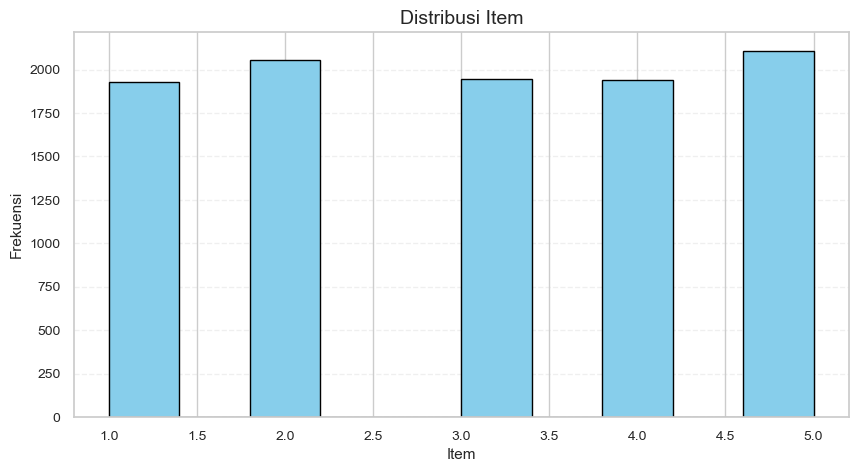

In [103]:
# Menampilkan histogram untuk melihat distribusi Quantity
plt.hist(df['Quantity'], bins=10, color='skyblue', edgecolor='black')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.title('Distribusi Item')
plt.xlabel('Item')
plt.ylabel('Frekuensi')
plt.show()

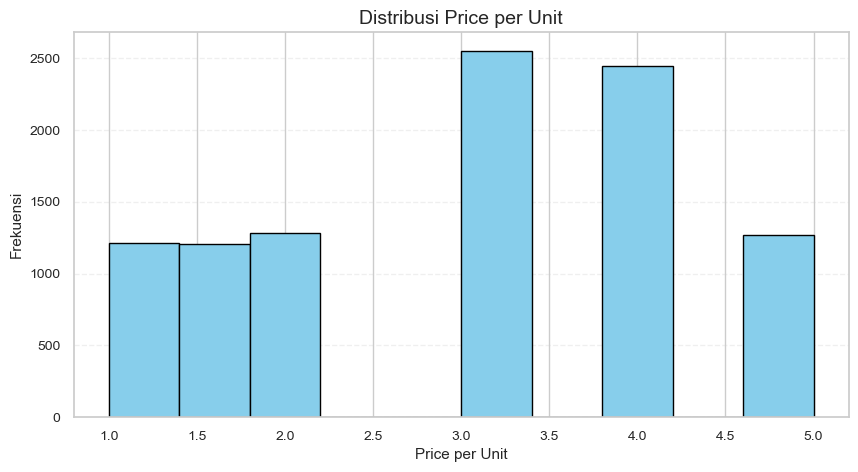

In [101]:
# Menampilkan histogram untuk melihat distribusi Price per Unit
plt.hist(df['Price Per Unit'], bins=10, color='skyblue', edgecolor='black')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.title('Distribusi Price per Unit')
plt.xlabel('Price per Unit')
plt.ylabel('Frekuensi')
plt.show()

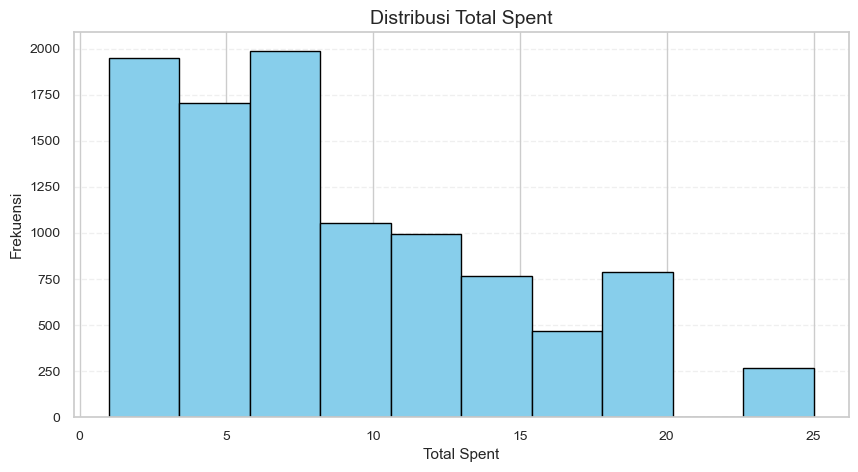

In [102]:
# Menampilkan histogram untuk melihat distribusi Total Spent
plt.hist(df['Total Spent'], bins=10, color='skyblue', edgecolor='black')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.title('Distribusi Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frekuensi')
plt.show()

Melihat tipe data

In [9]:
dfraw.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

Menghitung semua missing value pada setiap kolom

In [10]:
dfraw.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

# Data Cleaning
- Menangani missing values (menghapus atau mengisi dengan nilai tertentu).
- Menghapus duplikat data dan memperbaiki inkonsistensi format (misalnya huruf besar/kecil, spasi berlebih).
- Mengidentifikasi dan menangani outliers (menggunakan metode IQR atau z-score).

In [11]:
# buat semua status seperti <NA>, nan, UNKNOWN, nan, dan ERROR menjadi tipe2 null
df.replace(['<NA>', 'nan', 'UNKNOWN', 'ERROR'], pd.NA, inplace=True)


Sebelumnya sudah diketahui jika:
- COOKIE 1
- TEA 1.5
- COFFEE 2
- CAKE 3
- JUICE 3
- SMOOTHIE 4
- SANDWICH 4
- SALAD 5

In [12]:
# Dictionary harga berdasarkan item
listharga = {
    'Cookie': 1.0,
    'Tea': 1.5,
    'Coffee': 2.0,
    'Cake': 3.0,
    'Juice': 3.0,
    'Smoothie': 4.0,
    'Sandwich': 4.0,
    'Salad': 5.0
}

# 1. Isi Price Per Unit yang kosong berdasarkan Item
mask_price_from_item = (
    df['Price Per Unit'].isnull() &
    df['Item'].notnull()
)

df.loc[mask_price_from_item, 'Price Per Unit'] = (
    df.loc[mask_price_from_item, 'Item'].map(listharga)
)


# 2. Isi Price Per Unit yang kosong berdasarkan Total Spent / Quantity
mask_price_from_total = (
    df['Price Per Unit'].isnull() &
    df['Total Spent'].notnull() &
    df['Quantity'].notnull() &
    (df['Quantity'] != 0)
)

df.loc[mask_price_from_total, 'Price Per Unit'] = (
    df.loc[mask_price_from_total, 'Total Spent'] /
    df.loc[mask_price_from_total, 'Quantity']
)


# 3. Isi Total Spent yang kosong berdasarkan Quantity * Price Per Unit
mask_total = (
    df['Total Spent'].isnull() &
    df['Quantity'].notnull() &
    df['Price Per Unit'].notnull()
)

df.loc[mask_total, 'Total Spent'] = (
    df.loc[mask_total, 'Quantity'] *
    df.loc[mask_total, 'Price Per Unit']
)


# 4. Isi Quantity yang kosong berdasarkan Total Spent / Price Per Unit
mask_quantity = (
    df['Quantity'].isnull() &
    df['Total Spent'].notnull() &
    df['Price Per Unit'].notnull() &
    (df['Price Per Unit'] != 0)
)

df.loc[mask_quantity, 'Quantity'] = (
    df.loc[mask_quantity, 'Total Spent'] /
    df.loc[mask_quantity, 'Price Per Unit']
)

Selanjutnya, mensamakan nilai harga dengan item untuk memastikan tidak ada nilai null yang tersisa dan dimulai dari harga yang tidak sama terlebih dahulu

In [13]:
# Dictionary item berdasarkan harga yang hanya punya 1 kemungkinan item
list1item = {
    1.0: "Cookie",
    1.5: "Tea",
    2.0: "Coffee",
    5.0: "Salad"
}

# Isi Item yang kosong jika Price Per Unit sudah diketahui
mask_item = (
    df['Item'].isnull() &
    df['Price Per Unit'].isin(list1item.keys())
)

df.loc[mask_item, 'Item'] = (
    df.loc[mask_item, 'Price Per Unit'].map(list1item)
)

df[(df['Item'].isnull()) &(df['Price Per Unit'].notnull()) & ((df['Price Per Unit'] == 3.0) | (df['Price Per Unit'] == 4.0))]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
6,TXN_4433211,<NA>,3,3.0,9.0,<NA>,Takeaway,2023-10-06
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
36,TXN_6855453,<NA>,4,3.0,12.0,NaN,In-store,2023-07-17
61,TXN_8051289,NaN,1,3.0,3.0,NaN,In-store,2023-10-09
69,TXN_8471743,<NA>,5,3.0,15.0,Digital Wallet,In-store,2023-04-06
...,...,...,...,...,...,...,...,...
9910,TXN_2338617,<NA>,2,3.0,6.0,Digital Wallet,<NA>,2023-01-12
9918,TXN_2292088,<NA>,1,4.0,4.0,Digital Wallet,Takeaway,2023-03-04
9946,TXN_8807600,<NA>,1,4.0,4.0,Cash,Takeaway,2023-09-24
9981,TXN_4583012,<NA>,5,4.0,20.0,Digital Wallet,NaN,2023-02-27


Selanjutnya, membuat sistem untuk nilai 3.0 dan 4.0 yang memiliki 2 item yang berbeda

Untuk nilai 3.0, item yang mungkin adalah Juice atau Cake

Untuk nilai 4.0, item yang mungkin adalah Smoothie atau Sandwich

In [14]:
# Pertama-tama, menghitung total Juice dan total Cake
total_juice = df[df['Item'] == 'Juice']['Quantity'].sum()
total_cake = df[df['Item'] == 'Cake']['Quantity'].sum()

# Kemudian, menghitung total Smoothie dan total Sandwich
total_smoothie = df[df['Item'] == 'Smoothie']['Quantity'].sum()
total_sandwich = df[df['Item'] == 'Sandwich']['Quantity'].sum()

# Lalu menampilkan total untuk melihat seberapa besar perbandingan dari tiap Nilai
print("Total Juice:", total_juice)
print("Total Cake:", total_cake)
print("\nTotal Smoothie:", total_smoothie)
print("Total Sandwich:", total_sandwich)

Total Juice: 3505
Total Cake: 3468

Total Smoothie: 3336
Total Sandwich: 3429
